# Multifeature Linear Regression using Gradient Descent

# Objective

The objective of this project is to apply gradient descent to linear regression when the sample dataset has multiple features.
The goal is to learn how models separate the weights for each feature and how prediction work in vector form.

# Dataset Overview

For the project, the dataset used is the diabetes dataset from the sklearn library. It contains 442 samples with 10 features each. 

In [36]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added to sys.path:", project_root)

Project root added to sys.path: C:\Users\Admin\OneDrive\Desktop\ML\Gradient-descent\gradient-descent-linear-regression


In [37]:
#imports
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_multifeature_data
from src.linear_regression_gd import LinearRegressionGD

In [38]:
#Loading the data

X, y, feature_names = load_multifeature_data()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", len(feature_names))
print("Feature names:", feature_names)

X shape: (442, 10)
y shape: (442,)
Number of features: 10
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


# Shape Check

* Here X is 2D matrix with shape (n_samples, n_features).
* The target y is a 1D array of 442 elements, ie one output value for each sample.
* Also, y_pred will also be a 1D array containing one predicted value for each sample.

In [39]:
model = LinearRegressionGD(learning_rate=0.01, n_iters=1000)
model.fit(X, y)

print("Weights shape:", model.weight.shape)
print("Weights:", model.weight)
print("Bias:", model.bias)

Weights shape: (10,)
Weights: [  6.50828076   1.28806748  20.8265647   15.61326631   7.24508406
   5.85554099 -13.90078374  15.01590614  19.99313426  13.39901343]
Bias: 152.12691637061172


# Training the model
At this stage, the model starts with initial weights and bias, then updates them iteratively using gradient descent.
Since this is a multifeature problem, the weight parameter is now a vector rather than a single number.

# Model idea

For one feature, the prediction formula was:

ŷ = wX + b

For multiple features, each sample has several values, so the prediction becomes:

ŷ = (w1x1 + w2x2 + ... + wnxn) + b

This means the model learns one weight for each feature and combines them to produce one final prediction.
Gradient descent then updates all weights and the bias step by step to reduce the loss.

# Why simple visualization is harder here?
In a single-feature regression, we could plot a X vs y 2D plot. Similarly, for 2-feature regression, we can plot a 3D (2features + y) plot.
But here, it forms a higher-dimensional hyperplane, which cannot be visualized in a normal plot. 

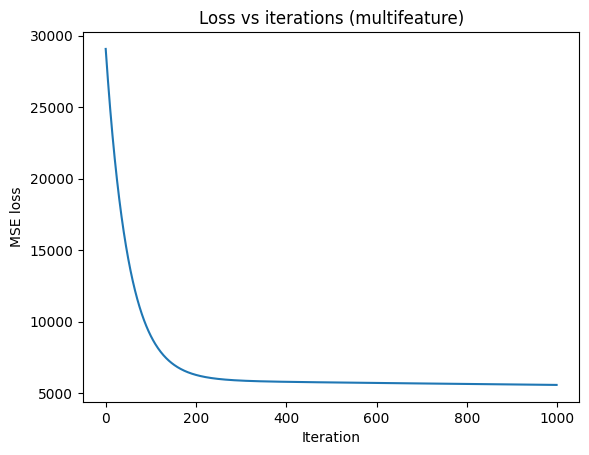

In [40]:
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE loss")
plt.title("Loss vs iterations (multifeature)")
plt.show()

# Loss Behaviour

The loss curve helps us to check whether gradient descent is actually learning.
If the loss decreases smoothly over iterations, it means the parameter updates are moving in the correct direction.
If it explodes or oscillates heavily, that usually suggests the learning rate is too large.
Also, the graph of loss will flatten out after reaching a certain value.

In [41]:
y_pred = model.predict(X)
mse = np.mean((y - y_pred) ** 2)
print("Train MSE:", mse)

Train MSE: 5568.4294621030385


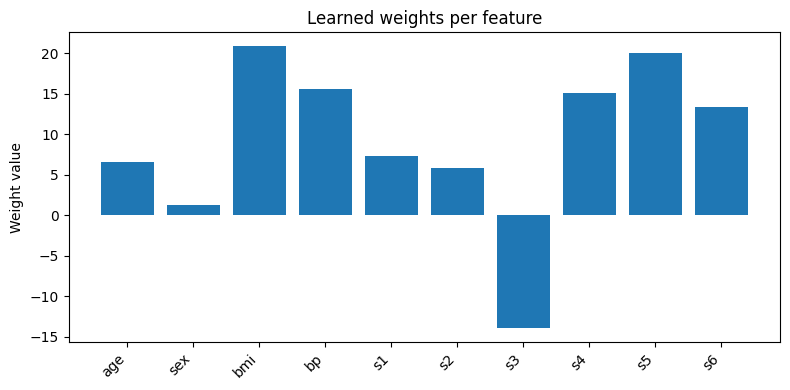

In [42]:
import matplotlib.pyplot as plt
import numpy as np

weights = model.weight
names = feature_names  # from your loader

plt.figure(figsize=(8, 4))
indices = np.arange(len(weights))
plt.bar(indices, weights)
plt.xticks(indices, names, rotation=45, ha="right")
plt.ylabel("Weight value")
plt.title("Learned weights per feature")
plt.tight_layout()
plt.show()

## Interpreting the weight plot

This bar chart shows one learned weight for each feature.
Features with larger positive weights tend to increase the prediction when they increase, while features with negative weights tend to decrease the prediction. The final prediction is a combination of all these effects.